## Pengolahan Citra Digital

In [3]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

import math

### Import or Read Image

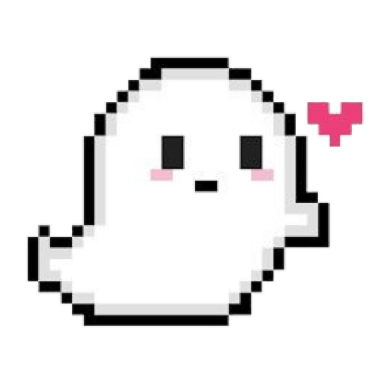

In [ ]:
img = cv2.imread("cute-ghost.png")
h, w, c = img.shape

img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

plt.imshow(img)
plt.axis("off")
plt.show()

### Mirroring Image

Mirroing image is the process of flipping an image across an axis (horizontal or vertical).
It’s like reflecting the image as if in a mirror.

- <b>Horizontal Mirror</b> \
For image with width `W`, the formula is:
$$ (x,y)⟶(W−1−x, y) $$

- <b>Vertical Mirror</b> \
For image with height `H`, the formula is:
$$ (x,y)⟶(x, H-1-y) $$

- <b>Combination Mirror</b> \
Combination of horizontal and vertical mirror. \
For width `W` and height `H`, the formula is:
$$ (x,y)⟶(W-1-x, H-1-y) $$

In [5]:
# mirror image
def horizontal_mirror(img):
    mirrored_img = np.zeros_like(img)
    h, w, c = img.shape

    for i in range(h):
        for j in range(w):
            mirrored_img[j, i] = img[w-j-1, i]
    return mirrored_img 
    
def vertical_mirror(img):
    mirrored_img = np.zeros_like(img)
    h, w, c = img.shape

    for i in range(h):
        for j in range(w):
            mirrored_img[i, j] = img[i, h-j-1]
    return mirrored_img

def combination_mirror(img):
    mirrored_img = np.zeros_like(img)
    h, w, c = img.shape

    for i in range(h):
        for j in range(w):
            mirrored_img[i, j] = img[h-i-1, w-j-1]
    return mirrored_img

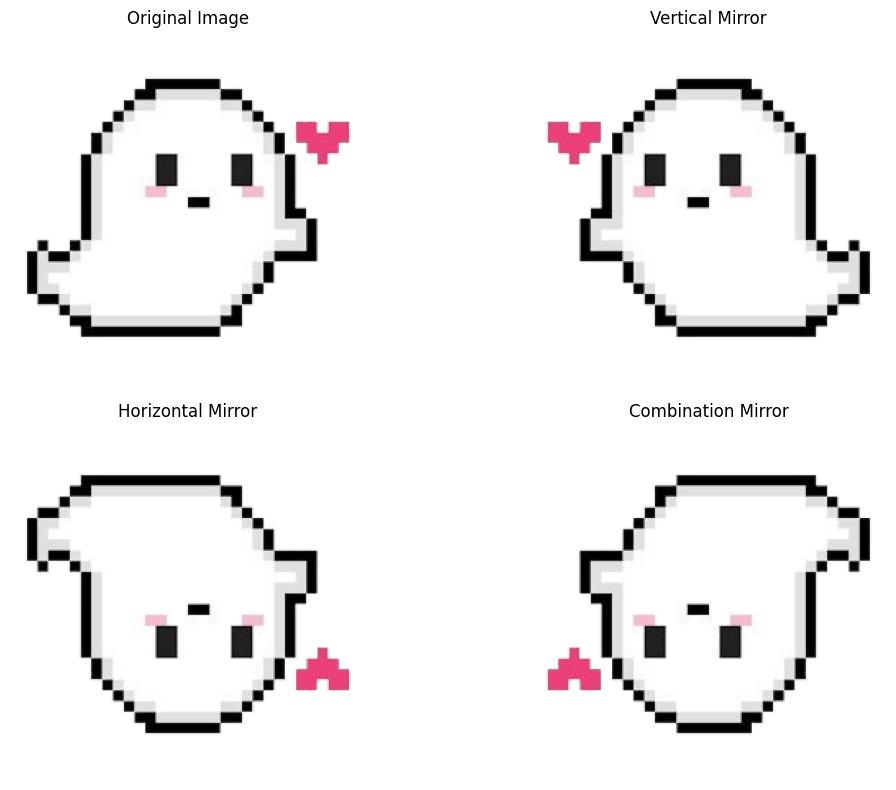

In [6]:
fig, axs = plt.subplots(2, 2, figsize=(12, 8))

axs[0, 0].imshow(img)
axs[0, 0].set_title("Original Image")
axs[0, 0].axis("off")

axs[0, 1].imshow(vertical_mirror(img))
axs[0, 1].set_title("Vertical Mirror")
axs[0, 1].axis("off")

axs[1, 0].imshow(horizontal_mirror(img))
axs[1, 0].set_title("Horizontal Mirror")
axs[1, 0].axis("off")

axs[1, 1].imshow(combination_mirror(img))
axs[1, 1].set_title("Combination Mirror")
axs[1, 1].axis("off")

plt.tight_layout()
plt.show()

### Rotating Image

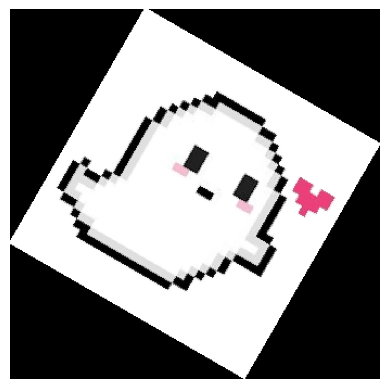

In [7]:
# rotate image
angle = 30
rad = np.deg2rad(angle)
cos_a = np.cos(rad)
sin_a = np.sin(rad)

new_h = int(abs(w * sin_a) + abs(h * cos_a))
new_w = int(abs(w * cos_a) + abs(h * sin_a))

rotated_image = np.zeros((new_h, new_w, c), dtype=np.uint8)

# center coordinates
cx, cy = w // 2, h // 2
ncx, ncy = new_w // 2, new_h // 2

for i in range(new_h):
    for j in range(new_w):
        # shift to center
        x = (j - ncx)
        y = (i - ncy)

        # inverse rotation
        src_x = int(x * cos_a + y * sin_a + cx)
        src_y = int(-x * sin_a + y * cos_a + cy)

        # check bounds
        if 0 <= src_x < w and 0 <= src_y < h:
            rotated_image[i, j] = img[src_y, src_x]
            
# show image
plt.imshow(rotated_image)
plt.axis("off")   # remove axes
plt.show()

### Negation Image

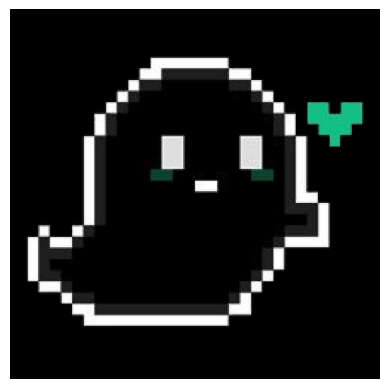

In [8]:
def negative_image(img):
    neg_img = 255 - img
    return neg_img

plt.imshow(negative_image(img))
plt.axis("off")
plt.show()

### Grayscale Image

In [86]:
def grayscale_image(img):
    h, w, c = img.shape
    gray_img = np.zeros((h, w), dtype=np.uint8)

    for i in range(h):
        for j in range(w):
            r, g, b = img[i, j]
            gray = int(0.299 * r + 0.587 * g + 0.114 * b)
            gray_img[i, j] = gray
    return gray_img

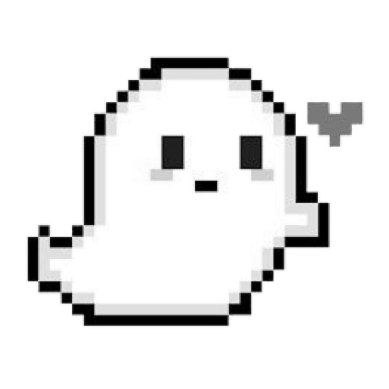

In [87]:
plt.imshow(grayscale_image(img), cmap='gray')
plt.axis("off")
plt.show()

### Thresholding Image

In [13]:
def thresholding_image(img, threshold = 128):
    gray_img = grayscale_image(img)
    thresh_img = np.zeros_like(gray_img)

    h, w = gray_img.shape

    for i in range(h):
        for j in range(w):
            if gray_img[i, j] >= threshold:
                thresh_img[i, j] = 255
            else:
                thresh_img[i, j] = 0
    return thresh_img

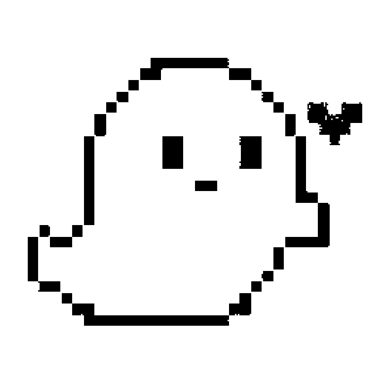

In [14]:
plt.imshow(thresholding_image(img), cmap='gray')
plt.axis("off")
plt.show()

### Negative + Thresholding = 50

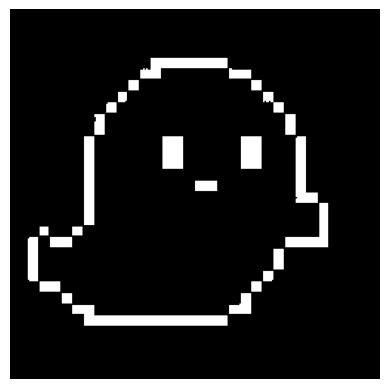

In [55]:
plt.imshow(negative_image(thresholding_image(img, threshold=50)), cmap='gray')
plt.axis("off")
plt.show()

### Scaling Image

In [21]:
def scaling_image(img, x_scale = 1, y_scale=1):
    h, w, c = img.shape
    new_h = int(h * y_scale)
    new_w = int(w * x_scale)
    new_image = np.zeros((new_h, new_w, c), dtype=np.uint8)

    for i in range(new_h):
        for j in range(new_w):
            src_x = int(j / x_scale)
            src_y = int(i / y_scale)

            if 0 <= src_x < w and 0 <= src_y < h:
                new_image[i, j] = img[src_y, src_x]

    return new_image

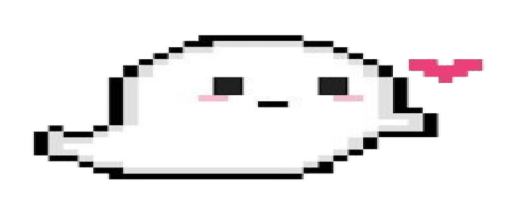

In [22]:
plt.imshow(scaling_image(img, 5, 2))
plt.axis("off")
plt.show()

### Gaussian Blur

In [53]:
# Gaussian Blur
def gaussian_blur(image, radius):
    sigma = max(radius / 2, 1.0)
    kernel_size = int(2 * radius + 1)

    kernel = np.zeros((kernel_size, kernel_size), dtype=np.float64)
    sum_val = 0.0

    for x in range(-radius, radius + 1):
        for y in range(-radius, radius + 1):
            exponent = -(x**2 + y**2) / (2 * sigma**2)
            value = (1 / (2 * math.pi * sigma**2)) * math.exp(exponent)
            kernel[x + radius, y + radius] = value
            sum_val += value

    kernel /= sum_val

    h, w, c = image.shape
    output = np.zeros_like(image, dtype=np.float64)

    for y in range(radius, h - radius):
        for x in range(radius, w - radius):
            region = image[y - radius:y + radius + 1, x - radius:x + radius + 1]
            for ch in range(c):
                output[y, x, ch] = np.sum(region[:, :, ch] * kernel)
    
    return output.astype(np.uint8)

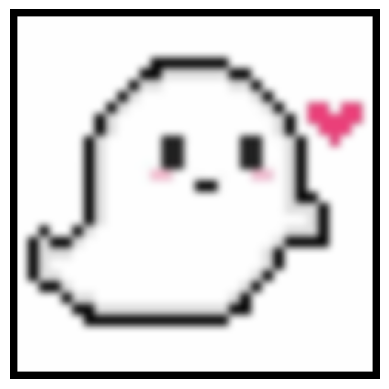

In [54]:
plt.imshow(gaussian_blur(img, 5))
plt.axis("off")
plt.show()